In [47]:

import pandas as pd
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


In [30]:
data_dir = Path("../data")

# All 7 CSV files that share the 16-column schema
csv_files = [
    data_dir / "Core-Processors-1.8.csv",
    data_dir / "Xeon-Processors-1.8.csv",
    data_dir / "Atom-Processors-1.9-16col.csv",
    data_dir / "Celeron-Processors-1.9-16col.csv",
    data_dir / "Core-Ultra-Processors-1.10-16col.csv",
    data_dir / "Intel-Processors-1.9-16col.csv",
    data_dir / "Pentium-Processors-1.9-16col.csv",
]

In [ ]:
# Read each file and collect the DataFrames
frames = []
for f in csv_files:
    print(f"Loading {f.name} ...")
    df = pd.read_csv(f)
    frames.append(df)

df = pd.concat(frames, ignore_index=True)
print(df.dtypes)

df["Release Year"] = df["Release Date"].str[-2:].astype(int) + 2000


features = ["Lithography(nm)", "Cores", "TDP(W)", "Release Year"]
allColumns = features.append("Max. Turbo Freq.(GHz)")

# Only convert the columns we actually need 
cols_to_clean = allColumns
for col in cols_to_clean:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dropna(subset=cols_to_clean, inplace=True)
print(f"Samples after cleaning: {len(df)}")

Loading Core-Processors-1.8.csv ...
Loading Xeon-Processors-1.8.csv ...
Loading Atom-Processors-1.9-16col.csv ...
Loading Celeron-Processors-1.9-16col.csv ...
Loading Core-Ultra-Processors-1.10-16col.csv ...
Loading Intel-Processors-1.9-16col.csv ...
Loading Pentium-Processors-1.9-16col.csv ...
Product                      str
Status                       str
Release Date                 str
Code Name                    str
Cores                      int64
Threads                  float64
Lithography(nm)          float64
Max. Turbo Freq.(GHz)    float64
Base Freq.(GHz)          float64
TDP(W)                   float64
Cache(MB)                float64
Cache Info                   str
Max Memory Size(GB)      float64
Memory Types                 str
Max Memory Speed(MHz)     object
Integrated Graphics          str
dtype: object


TypeError: 'NoneType' object is not iterable

In [61]:
X = df[features]
y = df["Max. Turbo Freq.(GHz)"]


print(f"Clean samples: {len(df)}")


Clean samples: 1855


In [68]:


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)



In [69]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [70]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)


In [71]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error


print("Training set:")
print(f"  R²   = {r2_score(y_train, y_pred_train):.4f}")
print(f"  MAE  = {mean_absolute_error(y_train, y_pred_train):.4f} GHz")
print(f"  RMSE = {root_mean_squared_error(y_train, y_pred_train):.4f} GHz")

print("\nTest set:")
print(f"  R²   = {r2_score(y_test, y_pred_test):.4f}")
print(f"  MAE  = {mean_absolute_error(y_test, y_pred_test):.4f} GHz")
print(f"  RMSE = {root_mean_squared_error(y_test, y_pred_test):.4f} GHz")



Training set:
  R²   = 1.0000
  MAE  = 0.0000 GHz
  RMSE = 0.0000 GHz

Test set:
  R²   = 1.0000
  MAE  = 0.0000 GHz
  RMSE = 0.0000 GHz


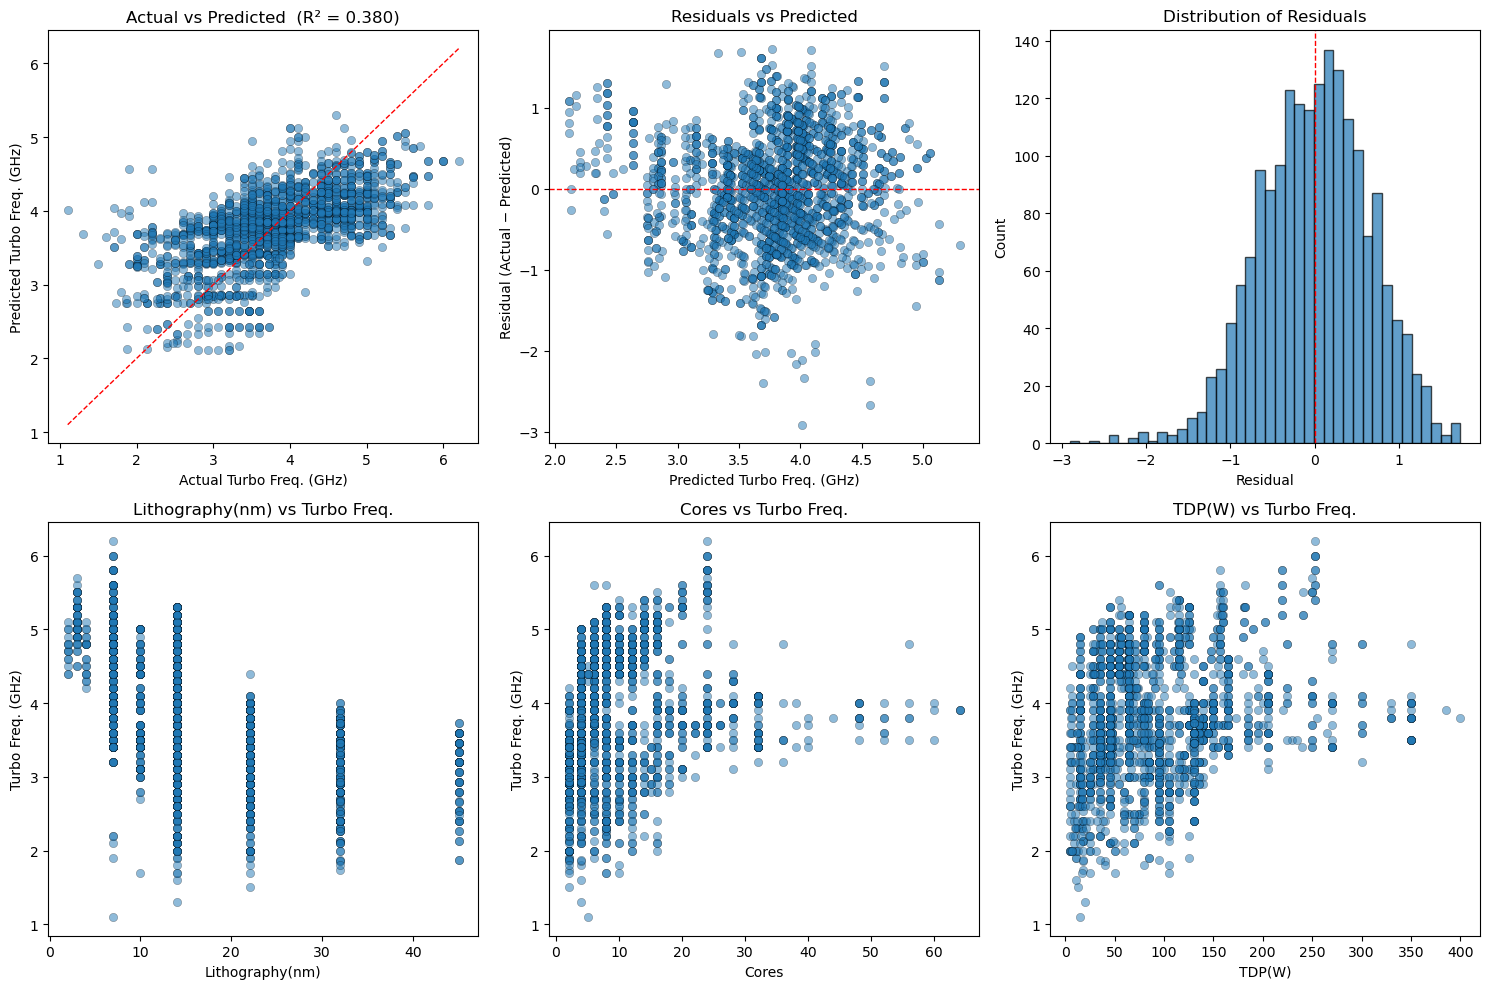

In [38]:
import matplotlib.pyplot as plt

# ── Predict ──────────────────────────────────────────────────
y_pred = model.predict(X_scaled)
residuals = y - y_pred

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1 ── Actual vs Predicted ────────────────────────────────────
ax = axes[0, 0]
ax.scatter(y, y_pred, alpha=0.5, edgecolors="k", linewidth=0.3)
ax.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=1)
ax.set_xlabel("Actual Turbo Freq. (GHz)")
ax.set_ylabel("Predicted Turbo Freq. (GHz)")
ax.set_title(f"Actual vs Predicted  (R² = {r2_score(y, y_pred):.3f})")

# 2 ── Residuals vs Predicted ─────────────────────────────────
ax = axes[0, 1]
ax.scatter(y_pred, residuals, alpha=0.5, edgecolors="k", linewidth=0.3)
ax.axhline(0, color="r", linestyle="--", linewidth=1)
ax.set_xlabel("Predicted Turbo Freq. (GHz)")
ax.set_ylabel("Residual (Actual − Predicted)")
ax.set_title("Residuals vs Predicted")

# 3 ── Histogram of Residuals ─────────────────────────────────
ax = axes[0, 2]
ax.hist(residuals, bins=40, edgecolor="k", alpha=0.7)
ax.axvline(0, color="r", linestyle="--", linewidth=1)
ax.set_xlabel("Residual")
ax.set_ylabel("Count")
ax.set_title("Distribution of Residuals")

# 4, 5, 6 ── Feature vs Target ────────────────────────────────
features = ["Lithography(nm)", "Cores", "TDP(W)"]
for i, (feat, ax) in enumerate(zip(features, [axes[1, 0], axes[1, 1], axes[1, 2]])):
    ax.scatter(X[feat], y, alpha=0.5, edgecolors="k", linewidth=0.3)
    ax.set_xlabel(feat)
    ax.set_ylabel("Turbo Freq. (GHz)")
    ax.set_title(f"{feat} vs Turbo Freq.")

plt.tight_layout()
plt.show()

In [ ]:
# No